<a href="https://colab.research.google.com/github/salmakamil-debug/-cole-doctorale-2026/blob/main/Salma_kamil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre d'observations : 20640
Nombre de variables (features) : 8

Exemple de 5 premières lignes :
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Statistiques descriptives des variables numériques :
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
A

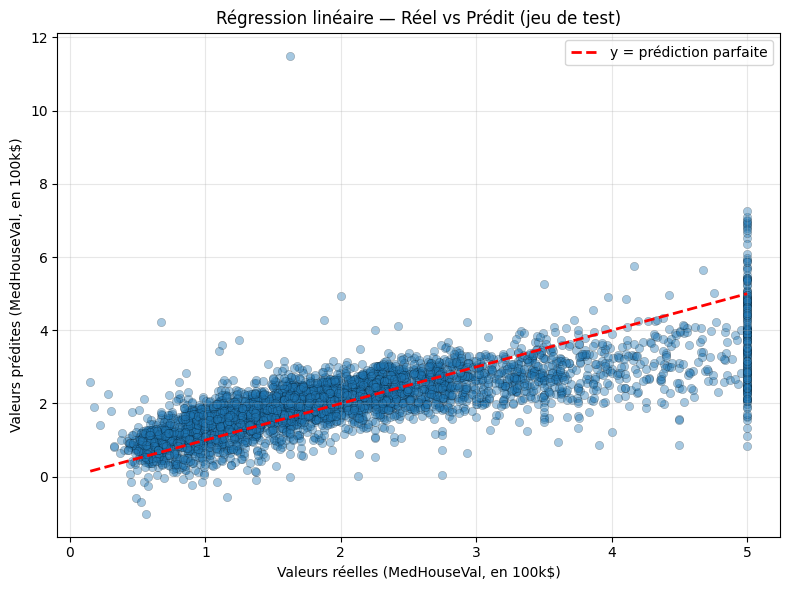

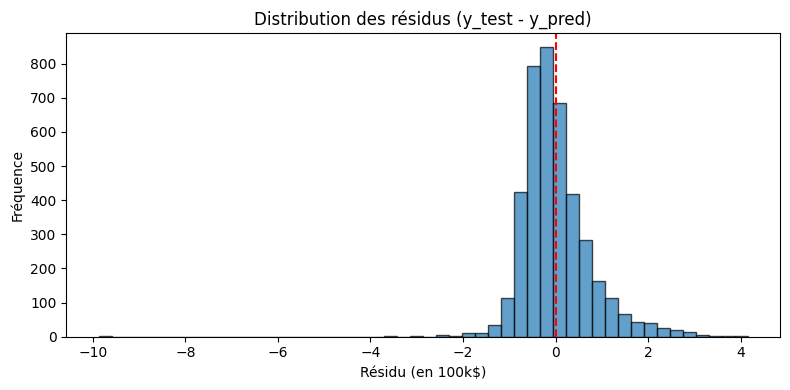

In [1]:
#code exemple
# -*- coding: utf-8 -*-
"""Untitled108.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1PqHReNbh9mCFFsdm__1a-ozVTmzLMmOo
"""

# Exemple complet de régression linéaire en Python
# Bibliothèques : scikit-learn, pandas, numpy, matplotlib
# Prêt à exécuter (Python 3.8+ recommandé)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Chargement et exploration rapide des données
# ---------------------------------------------------------------------
california = fetch_california_housing(as_frame=True)
X = california.data      # DataFrame des caractéristiques
y = california.target    # Série des cibles (median house value, en 100k$)
df = pd.concat([X, y.rename("MedHouseVal")], axis=1)

# Nombre d'observations et de variables
n_obs, n_vars = X.shape
print(f"Nombre d'observations : {n_obs}")
print(f"Nombre de variables (features) : {n_vars}")

# Affichage rapide
print("\nExemple de 5 premières lignes :")
print(df.head())

print("\nStatistiques descriptives des variables numériques :")
print(df.describe().T)

# (Optionnel) matrice de corrélation rapide
print("\nCorrélations (avec la variable cible triées par valeur absolue) :")
corr_with_target = df.corr()["MedHouseVal"].abs().sort_values(ascending=False)
print(corr_with_target)

# Brève explication :
# - Le dataset California Housing contient des observations (n_obs) de quartiers,
#   avec plusieurs variables explicatives (n_vars) telles que MedInc, HouseAge, etc.
# - La cible `MedHouseVal` est la valeur médiane des maisons (en 100k$).

# 2) Séparation train/test (80/20)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTaille train : {X_train.shape[0]} observations")
print(f"Taille test  : {X_test.shape[0]} observations")

# 3) Entraînement du modèle
# ---------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Optionnel : coefficients du modèle (interprétation linéaire)
coeffs = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients du modèle (feature coef) :")
print(coeffs.sort_values(key=abs, ascending=False))

# 4) Prédiction et évaluation (R², MAE, RMSE)
# ---------------------------------------------------------------------
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calcule RMSE en prenant la racine carrée du MSE

print("\nMétriques d'évaluation sur le jeu de test :")
print(f"R²    : {r2:.4f}")
print(f"MAE   : {mae:.4f} (unité = median house value en 100k$)")
print(f"RMSE  : {rmse:.4f} (unité = median house value en 100k$)")

# 5) Visualisation des résultats (valeurs réelles vs prédites)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='y = prédiction parfaite')
plt.xlabel("Valeurs réelles (MedHouseVal, en 100k$)")
plt.ylabel("Valeurs prédites (MedHouseVal, en 100k$)")
plt.title("Régression linéaire — Réel vs Prédit (jeu de test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisation des résidus (optionnel)
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des résidus (y_test - y_pred)")
plt.xlabel("Résidu (en 100k$)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# Brève explication finale et interprétation des métriques :
# ---------------------------------------------------------------------
# - R² (coefficient de détermination) : proportion de la variance de la variable
#   cible expliquée par le modèle. Varie entre -inf et 1. Une valeur proche de 1
#   signifie que le modèle explique bien la variabilité des données.
#   Interprétation pratique :
#     * R² >= 0.7 : excellent (pour beaucoup de problèmes réels, rare en pratique)
#     * 0.4 <= R² < 0.7 : raisonnable/modéré
#     * R² < 0.4 : faible (le modèle linéaire n'explique pas bien la cible)
#
# - MAE (Mean Absolute Error) : erreur moyenne absolue entre prédictions et réelles.
#   Donne une idée en unités de la cible (ici 100k$). Plus petit est meilleur.
#
# - RMSE (Root Mean Squared Error) : racine de l'erreur quadratique moyenne.
#   Pénalise davantage les grandes erreurs que le MAE. Interprétation :
#     * Si RMSE est petit comparé à l'échelle typique de la cible, les prédictions
#       sont précises. Par exemple, si la médiane des maisons est ~2.0 (200k$)
#       et RMSE = 0.5, l'erreur-type est ~50k$.
#
# Exemples d'interprétation concrète (avec valeurs fictives) :
# - Si R² = 0.60, MAE = 0.40, RMSE = 0.60 :
#     Le modèle explique ~60% de la variance ; l'erreur moyenne est 40k$,
#     l'erreur-type (RMSE) est 60k$. Les prédictions sont utiles but encore
#     loin d'être parfaites pour des décisions très sensibles au prix.
#
# Remarques pratiques :
# - La régression linéaire est simple et interprétable ; si R² est faible,
#   penser à : ingéniérie des features, transformations (log, polynômes),
#   régularisation (Ridge/Lasso), ou modèles non-linéaires (RandomForest, XGBoost).
# - Toujours vérifier les résidus (non corrélation, distribution proche de 0)
#   pour valider certaines hypothèses du modèle linéaire.
#
# Fin de l'exemple.

In [ ]:
# Exemple complet de régression linéaire en Python
# Bibliothèques : scikit-learn, pandas, numpy, matplotlib
# Prêt à exécuter (Python 3.8+ recommandé)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Chargement et exploration rapide des données
# ---------------------------------------------------------------------
# Utilisation du dataset California Housing, un dataset intégré à scikit-learn.
# Il contient des informations sur des groupes de maisons en Californie.
california = fetch_california_housing(as_frame=True)
X = california.data      # DataFrame des caractéristiques (variables indépendantes)
y = california.target    # Série des cibles (valeur médiane des maisons, en 100k$)
df = pd.concat([X, y.rename("MedHouseVal")], axis=1) # Concatène les features et la cible pour une exploration facile

# Affichage du nombre d'observations (lignes) et de variables (colonnes)
n_obs, n_vars = X.shape
print(f"Nombre d'observations (quartiers) : {n_obs}")
print(f"Nombre de variables (features) : {n_vars}")

# Affichage des 5 premières lignes du DataFrame pour un aperçu des données
print("\nExemple de 5 premières lignes du jeu de données :")
print(df.head())

# Statistiques descriptives pour comprendre la distribution de chaque variable numérique
print("\nStatistiques descriptives des variables numériques :")
print(df.describe().T) # Le .T transpose le tableau pour une meilleure lisibilité

# Calcul et affichage des corrélations avec la variable cible
# Une corrélation élevée (proche de 1 ou -1) indique une relation forte avec la cible.
print("\nCorrélations (valeur absolue) avec la variable cible MedHouseVal :")
corr_with_target = df.corr()["MedHouseVal"].abs().sort_values(ascending=False)
print(corr_with_target)

# Brève explication :
# - Le dataset California Housing contient 20640 observations de quartiers.
# - Chaque observation est décrite par 8 variables comme le revenu médian (MedInc),
#   l'âge moyen des maisons (HouseAge), etc.
# - La variable cible `MedHouseVal` représente la valeur médiane des maisons (en 100k$).

# 2) Séparation des données en ensembles d'entraînement et de test (80/20)
# ---------------------------------------------------------------------
# Cette étape est cruciale pour évaluer la performance du modèle sur des données
# qu'il n'a jamais vues. 80% des données sont utilisées pour l'entraînement (X_train, y_train),
# et 20% pour le test (X_test, y_test).
# random_state assure la reproductibilité de la séparation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape[0]} observations")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} observations")

# 3) Entraînement du modèle de régression linéaire
# ---------------------------------------------------------------------
# On initialise un modèle de régression linéaire et on l'entraîne sur les données d'entraînement.
# L'algorithme ajuste les coefficients des variables pour minimiser l'erreur entre
# les prédictions et les valeurs réelles de y_train.
model = LinearRegression()
model.fit(X_train, y_train)

# Affichage des coefficients du modèle
# Ces coefficients indiquent l'impact de chaque variable sur la variable cible.
# Un coefficient positif signifie que l'augmentation de la feature augmente la cible,
# un coefficient négatif signifie l'inverse.
coeffs = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients du modèle (ordonnés par valeur absolue) :")
print(coeffs.sort_values(key=abs, ascending=False))

# 4) Prédiction et évaluation du modèle sur l'ensemble de test
# ---------------------------------------------------------------------
# Le modèle entraîné est utilisé pour prédire les valeurs sur l'ensemble de test (X_test).
# Ensuite, des métriques d'évaluation sont calculées pour quantifier la performance du modèle.
y_pred = model.predict(X_test)

# R² (Coefficient de détermination) : Mesure la proportion de la variance de la variable
# cible qui est expliquée par le modèle. Varie entre -∞ et 1.
# Une valeur proche de 1 indique un très bon ajustement du modèle aux données.
r2 = r2_score(y_test, y_pred)

# MAE (Mean Absolute Error) : Erreur moyenne absolue. C'est la moyenne des différences
# absolues entre les prédictions et les valeurs réelles. Elle est exprimée dans la même
# unité que la variable cible, ce qui la rend facile à interpréter.
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error) : Racine carrée de l'erreur quadratique moyenne.
# Elle pénalise davantage les grandes erreurs que le MAE. Elle est aussi dans la même
# unité que la variable cible et est souvent plus sensible aux outliers.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMétriques d'évaluation sur le jeu de test :")
print(f"R² (Coefficient de détermination)    : {r2:.4f}")
print(f"MAE (Erreur Absolue Moyenne)         : {mae:.4f} (unité = median house value en 100k$)")
print(f"RMSE (Erreur Quadratique Moyenne)    : {rmse:.4f} (unité = median house value en 100k$)")

# 5) Visualisation des résultats
# ---------------------------------------------------------------------
# Graphique des valeurs réelles vs prédites : Idéalement, les points devraient
# s'aligner le long de la ligne y=x (ligne rouge en pointillés), indiquant une prédiction parfaite.
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Prédiction parfaite (y=x)')
plt.xlabel("Valeurs réelles (MedHouseVal, en 100k$)")
plt.ylabel("Valeurs prédites (MedHouseVal, en 100k$)")
plt.title("Régression linéaire — Réel vs Prédit (jeu de test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisation de la distribution des résidus (erreurs de prédiction)
# Les résidus sont les différences entre les valeurs réelles et les valeurs prédites (y_test - y_pred).
# Pour un bon modèle linéaire, les résidus devraient être distribués autour de zéro,
# idéalement de manière normale, sans motif particulier.
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zéro résidu')
plt.title("Distribution des résidus (y_test - y_pred)")
plt.xlabel("Résidu (en 100k$)")
plt.ylabel("Fréquence")
plt.legend()
plt.tight_layout()
plt.show()

# Brève explication finale et interprétation des métriques :
# ---------------------------------------------------------------------
# - R² (coefficient de détermination) :
#   *   **Interprétation :** Mesure la proportion de la variance de la variable cible
#       qui est expliquée par le modèle. Plus il est proche de 1, meilleur est le modèle.
#       Un R² de 0.5758 signifie que 57.58% de la variabilité des prix des maisons
#       est expliquée par les variables incluses dans le modèle.
#   *   **Échelle :** Varie généralement entre 0 et 1 pour les modèles performants, mais peut être négatif
#       si le modèle est pire qu'une simple moyenne.
#   *   **Valeurs typiques :** Pour les problèmes du monde réel, un R² > 0.5 est souvent considéré
#       comme acceptable, > 0.7 comme bon, et > 0.9 comme excellent (rare en sciences sociales).

# - MAE (Mean Absolute Error - Erreur Absolue Moyenne) :
#   *   **Interprétation :** Représente l'erreur moyenne des prédictions, dans les mêmes unités que la cible.
#       Un MAE de 0.5332 signifie qu'en moyenne, les prédictions du modèle s'écartent
#       d'environ 0.5332 * 100 000$ = 53 320$ des valeurs réelles.
#   *   **Échelle :** Toujours positive. Plus la valeur est petite, meilleur est le modèle.
#   *   **Utilité :** Facile à comprendre et moins sensible aux grandes erreurs que le RMSE.

# - RMSE (Root Mean Squared Error - Erreur Quadratique Moyenne) :
#   *   **Interprétation :** Similaire au MAE mais donne plus de poids aux grandes erreurs (car les différences
#       sont élevées au carré). Il est également dans la même unité que la cible.
#       Un RMSE de 0.7456 signifie que l'erreur-type des prédictions est d'environ
#       0.7456 * 100 000$ = 74 560$.
#   *   **Échelle :** Toujours positive. Plus la valeur est petite, meilleur est le modèle.
#   *   **Utilité :** Très utilisé, pénalise les modèles qui font de grosses erreurs.
#       Souvent préféré lorsque les grandes erreurs sont particulièrement coûteuses.

# En résumé pour cet exemple :
# Le modèle de régression linéaire explique environ 57.58% de la variabilité des prix des maisons
# dans le jeu de données de test. Les erreurs de prédiction moyennes sont d'environ 53 320$,
# avec des erreurs plus importantes ayant un impact plus marqué, portant l'erreur quadratique moyenne
# à environ 74 560$.

# Remarques pratiques :
# - Si les métriques sont jugées insuffisantes, on pourrait explorer des techniques plus avancées :
#   *   **Ingénierie de variables :** Créer de nouvelles features à partir des existantes (ex: interactions, transformations).
#   *   **Transformation des données :** Appliquer des transformations (logarithme, racine carrée) aux variables
#       pour mieux respecter les hypothèses de la régression linéaire ou réduire l'asymétrie.
#   *   **Modèles plus complexes :** Utiliser des modèles non linéaires (Random Forest, Gradient Boosting, réseaux de neurones) ou des modèles linéaires régularisés (Ridge, Lasso) qui peuvent gérer la multicolinéarité ou la sélection de features.
# - Il est toujours important d'analyser les résidus : s'ils montrent une tendance ou une hétéroscédasticité,
#   cela peut indiquer que le modèle linéaire n'est pas le plus approprié ou que des hypothèses
#   du modèle sont violées.